# Inventory Analysis - Reorder Predictor

## Single product

Predict demand and reoder point for a product in a dark store

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)

# Synthetic daily demand for Red Bull 4-pack
# Imagine this is 3 weeks of data at a new Minneapolis dark store
n_days = 21
true_mu = 18      # true avg daily demand (we're pretending we know this)

observed_demand = np.random.poisson(true_mu, n_days).clip(0)
# clip at 0 because negative demand doesn't exist

print(observed_demand)

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


[21 13 19 23 13 15 17 19 15 17 14 19 19 15 20 12 15 15 19 26 11]


Poisson Data -> Gamma Distribution -> Uninformative Prior

In [ ]:
with pm.Model() as inventory_model:

    # --- Priors ---
    # Prior on average daily demand
    mu = pm.Gamma("mu", alpha=2, beta=0.1)  # Gamma pairs naturally with Poisson
                                             # and enforces mu > 0

    # --- Likelihood ---
    # Likelihood — Poisson instead of Normal
    demand_obs = pm.Poisson("demand_obs", mu=mu, observed=observed_demand)

    # --- Sample ---
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.


- Not multi-modal
- Fuzzy caterpillar

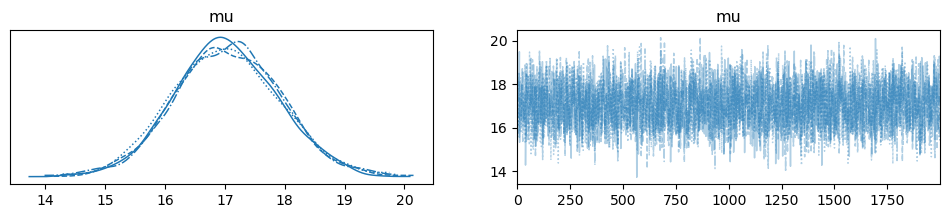

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,17.035,0.889,15.297,18.643,0.016,0.009,3184.0,5995.0,1.0


In [3]:
# Sampler diagnostics
az.plot_trace(trace, var_names=["mu"])
plt.show()

# Posterior summary
az.summary(trace, var_names=["mu"])

1. We made up the lead time based on experience
2. We made up the 95% stock level based on experience
3. Grab posterior samples from distribution & plug into basic formulas for reorder points

In [5]:
# Pull posterior samples
mu_samples = trace.posterior["mu"].values.flatten()       # shape: (4000,)

# Business parameters
lead_time = 2    # days from reorder to delivery
service_level = 0.95  # we want to be in stock 95% of the time
Z = 1.65         # Z-score for 95th percentile

# --- Compute reorder point for each posterior sample ---
# This propagates uncertainty through the business formula
expected_demand_lt = mu_samples * lead_time
safety_stock = Z * np.sqrt(expected_demand_lt)  # Poisson variance = mean
reorder_point_samples = expected_demand_lt + safety_stock

# --- Summarize ---
print(f"Reorder Point (mean):        {reorder_point_samples.mean():.1f} units")
print(f"Reorder Point (5th pct):     {np.percentile(reorder_point_samples, 5):.1f} units")
print(f"Reorder Point (95th pct):    {np.percentile(reorder_point_samples, 95):.1f} units")

Reorder Point (mean):        43.7 units
Reorder Point (5th pct):     40.4 units
Reorder Point (95th pct):    47.0 units


Plot demand and reorder distributions

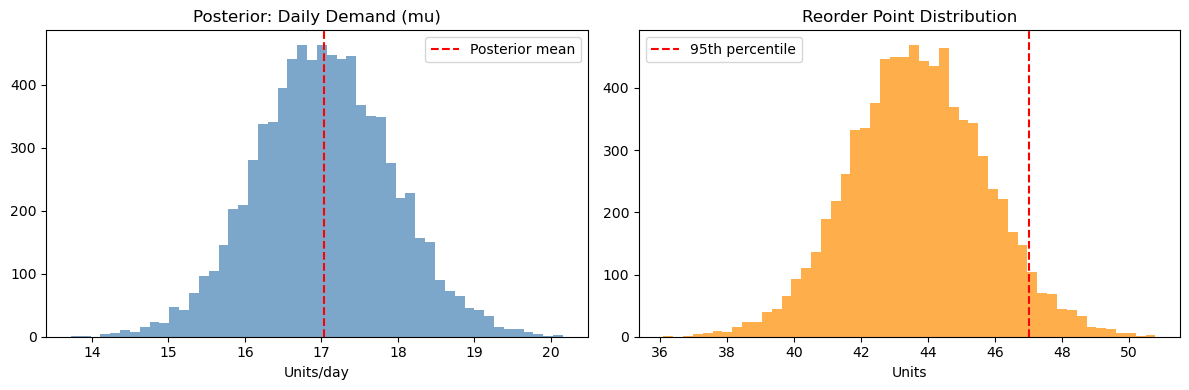

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: posterior of mu
axes[0].hist(mu_samples, bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(mu_samples.mean(), color="red", linestyle="--", label="Posterior mean")
axes[0].set_title("Posterior: Daily Demand (mu)")
axes[0].set_xlabel("Units/day")
axes[0].legend()

# Right: reorder point distribution
axes[1].hist(reorder_point_samples, bins=50, color="darkorange", alpha=0.7)
axes[1].axvline(np.percentile(reorder_point_samples, 95),
                color="red", linestyle="--", label="95th percentile")
axes[1].set_title("Reorder Point Distribution")
axes[1].set_xlabel("Units")
axes[1].legend()

plt.tight_layout()
plt.show()

Run a few scenarios
1. New SKU, no data
2. New store, existing SKU
3. Seasonal SKU, had it last year

My thoughts
Let's say you're red bull, and on average you have 10% greater demand than monster, could you just take monster and add 10% and use that as a prior? Or could you say that in this one store that's similar to the new dark store, you have 15% greater sales than monster, so take monster and add 15%? Or if the store is new to everyone, you could take the most similar stores and average them for red bull sales, but would you need to take the lower credible interval because it's new and might take some time to get going?

- This is all about making new priors
- Instead of taking low CI, make wider distribution
- Transfer learning in Bayesian Inference
- Todays posterior becomes tomorrows prior (lol kind of)

In [9]:
# # Scenario A: Brand new SKU, no history — wide prior, let data speak
# mu = pm.Gamma("mu", alpha=2, beta=0.1)

# # Scenario B: New dark store, but SKU exists in 10 other stores
# # You know from other stores avg demand is ~18, std ~3
# mu = pm.Gamma("mu", alpha=(18**2)/(3**2), beta=18/(3**2))   # tighter prior, more confident

# # Scenario C: Seasonal SKU, you have last year's data
# # Use last year's posterior as this year's prior — full Bayesian updating
# mu = pm.Normal("mu", mu=last_year_mu, sigma=last_year_sigma)

## Multi-Product
- Same product, multiple stores!

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

# Store metadata
stores = [
    {"id": 0, "name": "Minneapolis",   "days": 90, "true_mu": 18},
    {"id": 1, "name": "St. Paul",      "days": 90, "true_mu": 15},
    {"id": 2, "name": "Chicago",       "days": 60, "true_mu": 25},
    {"id": 3, "name": "Chicago North", "days": 60, "true_mu": 22},
    {"id": 4, "name": "Milwaukee",     "days": 30, "true_mu": 14},
    {"id": 5, "name": "Madison",       "days": 30, "true_mu": 12},
    {"id": 6, "name": "Indianapolis",  "days": 7,  "true_mu": 20},
    {"id": 7, "name": "Columbus",      "days": 7,  "true_mu": 11},
]

n_stores = len(stores)

# Build long-format dataframe — one row per store per day
rows = []
for store in stores:
    demand = np.random.poisson(lam=store["true_mu"], size=store["days"])
    for d, units in enumerate(demand):
        rows.append({
            "store_id":   store["id"],
            "store_name": store["name"],
            "day":        d,
            "units_sold": units
        })

df = pd.DataFrame(rows)

# Arrays for PyMC
store_idx    = df["store_id"].values       # which store each row belongs to
units_sold   = df["units_sold"].values     # observed demand

print(df.groupby("store_name")["units_sold"].agg(["count", "mean", "std"]).round(2))

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


               count   mean   std
store_name                       
Chicago           60  24.50  5.36
Chicago North     60  20.58  4.16
Columbus           7  10.86  2.54
Indianapolis       7  17.43  3.60
Madison           30  11.67  3.07
Milwaukee         30  13.90  3.43
Minneapolis       90  18.17  4.24
St. Paul          90  14.59  4.34


In [2]:
df.head()

,store_id,store_name,day,units_sold
0,0,Minneapolis,0,21
1,0,Minneapolis,1,13
2,0,Minneapolis,2,19
3,0,Minneapolis,3,23
4,0,Minneapolis,4,13


Share information across stores from the product

In [3]:
with pm.Model() as hierarchical_inventory:

    # --- Hyperpriors (population level) ---
    # What does demand look like across ALL GoPuff stores for this SKU?
    # This is the "population distribution" all stores draw from

    # We think average demand across stores is somewhere around 15-25/day
    mu_population = pm.Gamma("mu_population", alpha=4, beta=0.2)

    # How much do stores vary from each other?
    # HalfNormal because variance must be positive
    sigma_population = pm.HalfNormal("sigma_population", sigma=5)

    # --- Store-level parameters ---
    # Each store gets its own mu, but drawn from the population distribution
    # shape=n_stores gives one mu per store
    mu_store = pm.Normal("mu_store",
                          mu=mu_population,
                          sigma=sigma_population,
                          shape=n_stores)

    # --- Likelihood ---
    # store_idx maps each observation to the right store's mu
    demand_obs = pm.Poisson("demand_obs",
                             mu=mu_store[store_idx],
                             observed=units_sold)

    # --- Sample ---
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_population, sigma_population, mu_store]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


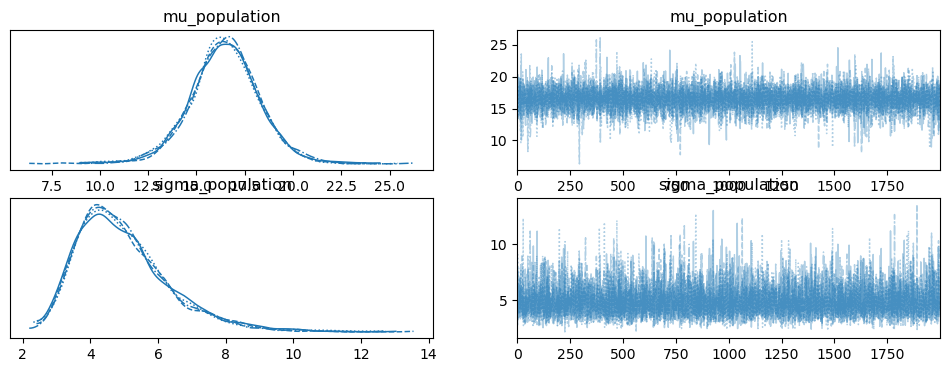

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_population,16.444,1.830,13.175,20.075,0.020,0.030,9662.0,4105.0,1.0
mu_store[0],18.157,0.452,17.315,19.008,0.004,0.006,15582.0,5459.0,1.0
mu_store[1],14.611,0.407,13.871,15.394,0.003,0.005,16813.0,6094.0,1.0
mu_store[2],24.363,0.635,23.184,25.530,0.005,0.008,17988.0,5429.0,1.0
mu_store[3],20.527,0.577,19.422,21.573,0.005,0.007,14223.0,6418.0,1.0
mu_store[4],13.995,0.669,12.745,15.232,0.005,0.009,15132.0,5659.0,1.0
mu_store[5],11.789,0.626,10.568,12.921,0.005,0.008,15372.0,6025.0,1.0
mu_store[6],17.431,1.503,14.644,20.252,0.012,0.020,14837.0,5814.0,1.0
mu_store[7],11.387,1.253,9.133,13.770,0.010,0.016,16493.0,5922.0,1.0


In [4]:
az.plot_trace(trace, var_names=["mu_population", "sigma_population"])
plt.show()

az.summary(trace, var_names=["mu_population", "mu_store"])

Graph it up

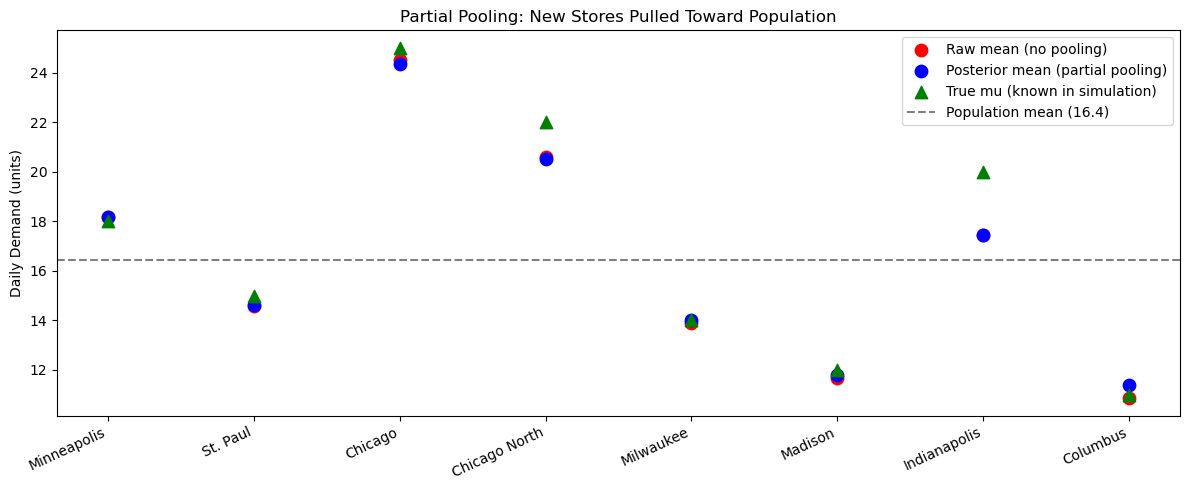

In [5]:
# Raw means per store (no pooling)
raw_means = df.groupby("store_id")["units_sold"].mean().values

# Posterior means per store (partial pooling)
posterior_means = trace.posterior["mu_store"].mean(dim=["chain", "draw"]).values

# Population mean (full pooling)
population_mean = trace.posterior["mu_population"].mean().item()

store_names = [s["name"] for s in stores]
true_mus    = [s["true_mu"] for s in stores]

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(n_stores)
ax.scatter(x, raw_means,       label="Raw mean (no pooling)",      color="red",    s=80, zorder=3)
ax.scatter(x, posterior_means, label="Posterior mean (partial pooling)", color="blue", s=80, zorder=3)
ax.scatter(x, true_mus,        label="True mu (known in simulation)", color="green", s=80, marker="^", zorder=3)
ax.axhline(population_mean, linestyle="--", color="gray", label=f"Population mean ({population_mean:.1f})")

ax.set_xticks(x)
ax.set_xticklabels(store_names, rotation=25, ha="right")
ax.set_ylabel("Daily Demand (units)")
ax.set_title("Partial Pooling: New Stores Pulled Toward Population")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
lead_time     = 2
service_level = 0.95
Z             = 1.65

# Pull posterior samples — shape is (chains * draws, n_stores)
mu_samples = trace.posterior["mu_store"].values.reshape(-1, n_stores)

# Compute reorder point distribution per store
reorder_points = mu_samples * lead_time + Z * np.sqrt(mu_samples * lead_time)
# Note: for Poisson, variance = mu, so sigma = sqrt(mu)
# So safety stock = Z * sqrt(mu * lead_time)

# Summarize
print(f"\n{'Store':<18} {'Raw Mean':>10} {'ROP Mean':>10} {'ROP 75th':>10} {'ROP 95th':>10}")
print("-" * 55)
for i, store in enumerate(stores):
    rop = reorder_points[:, i]
    print(f"{store['name']:<18} {raw_means[i]:>10.1f} {rop.mean():>10.1f} "
          f"{np.percentile(rop, 75):>10.1f} {np.percentile(rop, 95):>10.1f}")


Store                Raw Mean   ROP Mean   ROP 75th   ROP 95th
-------------------------------------------------------
Minneapolis              18.2       46.3       47.0       48.0
St. Paul                 14.6       38.1       38.8       39.7
Chicago                  24.5       60.2       61.2       62.6
Chicago North            20.6       51.6       52.5       53.8
Milwaukee                13.9       36.7       37.8       39.3
Madison                  11.7       31.6       32.6       34.0
Indianapolis             17.4       44.6       46.9       50.3
Columbus                 10.9       30.6       32.5       35.5


Sampling: [demand_obs]


Output()

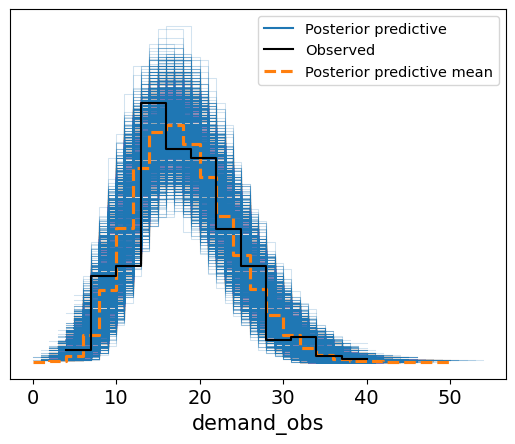

In [9]:
with hierarchical_inventory:
    ppc = pm.sample_posterior_predictive(trace)

az.plot_ppc(ppc, observed_rug=True)
plt.show()

***